# AISO v4 — Velocity (관성) 추가

## 왜 v3가 실패했나
- AISO는 acceptance-based (greedy) → `X[i]`는 항상 더 좋은 위치로만 이동
- 따라서 `p_best ≈ X[i]` 항상 → `φ·(p_best - X[i]) ≈ 0` → 무효

## v4 핵심 아이디어
| | PSO | AISO_v4 |
|---|---|---|
| 관성 | `w·v` | `w·v` (동일) |
| 사회 항 | `c1·r1·(p_best-X) + c2·r2·(g_best-X)` | `α·c_ij·(X[j]-X[i])` ← **타입 상성이 방향 결정** |
| 위치 업데이트 | 항상 | 항상 (acceptance 제거) |
| 타입 업데이트 | 없음 | 개선 시에만 W 갱신 |

**PSO와 차별점**: 사회적 영향력이 랜덤(r2)이 아니라 타입 상성(c_ij)으로 결정됨.  
호환 타입 파트너는 강하게 따라가고, 비호환 타입은 약하게 따라감.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

K        = 30
N_AGENTS = 30
N_ITER   = 100
N_RUNS   = 20
N_TYPES  = 12
ALPHA    = 0.3
BETA     = 0.1
NOISE_SD = 1.0

# v4 velocity params
W_INERTIA = 0.729   # PSO와 동일한 관성 계수
V_CLAMP   = 0.2     # velocity clamp (폭주 방지)

np.random.seed(42)
print(f'K={K} | N_AGENTS={N_AGENTS} | N_ITER={N_ITER} | N_RUNS={N_RUNS}')
print(f'v4 params: W_INERTIA={W_INERTIA}, ALPHA={ALPHA}, V_CLAMP={V_CLAMP}')

K=30 | N_AGENTS=30 | N_ITER=100 | N_RUNS=20
v4 params: W_INERTIA=0.729, ALPHA=0.3, V_CLAMP=0.2


In [2]:
# 벤치마크 함수 (v3와 동일)
def make_sphere(noise=0.0):
    def f(x):
        z = x*10-5
        return float(np.sum(z**2)+np.random.randn()*noise)
    f.__name__='Sphere'+('_N' if noise else ''); return f

def make_rastrigin(noise=0.0):
    def f(x):
        z=x*10.24-5.12
        return float(10*len(z)+np.sum(z**2-10*np.cos(2*np.pi*z))+np.random.randn()*noise)
    f.__name__='Rastrigin'+('_N' if noise else ''); return f

def make_ackley(noise=0.0):
    def f(x):
        z=x*64-32; n=len(z)
        return float(-20*np.exp(-0.2*np.sqrt(np.sum(z**2)/n))
                     -np.exp(np.sum(np.cos(2*np.pi*z))/n)+np.e+20+np.random.randn()*noise)
    f.__name__='Ackley'+('_N' if noise else ''); return f

def make_griewank(noise=0.0):
    def f(x):
        z=x*1200-600; i=np.arange(1,len(z)+1)
        return float(np.sum(z**2)/4000-np.prod(np.cos(z/np.sqrt(i)))+1+np.random.randn()*noise)
    f.__name__='Griewank'+('_N' if noise else ''); return f

def make_rosenbrock(noise=0.0):
    def f(x):
        z=x*4-2
        return float(np.sum(100*(z[1:]-z[:-1]**2)**2+(z[:-1]-1)**2)+np.random.randn()*noise)
    f.__name__='Rosenbrock'+('_N' if noise else ''); return f

def make_levy(noise=0.0):
    def f(x):
        z=x*20-10; w=1+(z-1)/4
        return float((np.sin(np.pi*w[0]))**2
                     +np.sum((w[:-1]-1)**2*(1+10*np.sin(np.pi*w[:-1]+1)**2))
                     +(w[-1]-1)**2*(1+np.sin(2*np.pi*w[-1])**2)+np.random.randn()*noise)
    f.__name__='Levy'+('_N' if noise else ''); return f

def make_schwefel(noise=0.0):
    def f(x):
        z=x*1000-500
        return float(418.9829*len(z)-np.sum(z*np.sin(np.sqrt(np.abs(z))))+np.random.randn()*noise)
    f.__name__='Schwefel'+('_N' if noise else ''); return f

def make_styblinski(noise=0.0):
    def f(x):
        z=x*10-5
        return float(0.5*np.sum(z**4-16*z**2+5*z)+39.166*len(z)+np.random.randn()*noise)
    f.__name__='Styblinski'+('_N' if noise else ''); return f

def make_zakharov(noise=0.0):
    def f(x):
        z=x*10-5; i=np.arange(1,len(z)+1); s=np.sum(0.5*i*z)
        return float(np.sum(z**2)+s**2+s**4+np.random.randn()*noise)
    f.__name__='Zakharov'+('_N' if noise else ''); return f

def make_dixon_price(noise=0.0):
    def f(x):
        z=x*20-10; i=np.arange(2,len(z)+1)
        return float((z[0]-1)**2+np.sum(i*(2*z[1:]**2-z[:-1])**2)+np.random.randn()*noise)
    f.__name__='Dixon-Price'+('_N' if noise else ''); return f

BENCHMARKS = [
    make_sphere(), make_rosenbrock(), make_zakharov(), make_dixon_price(),
    make_rastrigin(), make_ackley(), make_griewank(), make_levy(),
    make_schwefel(), make_styblinski(),
    make_sphere(noise=NOISE_SD), make_ackley(noise=NOISE_SD), make_rastrigin(noise=NOISE_SD),
]
print(f'벤치마크 {len(BENCHMARKS)}개 준비')

벤치마크 13개 준비


## 알고리즘

In [3]:
# ── PSO (기준선) ──────────────────────────────────────────────
def run_pso(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    w, c1, c2 = 0.729, 1.494, 1.494
    X = np.random.rand(n_agents, K)
    V = np.random.uniform(-0.1, 0.1, (n_agents, K))
    S = np.array([f(X[i]) for i in range(n_agents)])
    pX = X.copy(); pS = S.copy()
    gi = np.argmin(pS); gX = pX[gi].copy(); gS = pS[gi]
    for _ in range(n_iter):
        r1, r2 = np.random.rand(n_agents, K), np.random.rand(n_agents, K)
        V = w*V + c1*r1*(pX-X) + c2*r2*(gX-X)
        X = np.clip(X+V, 0, 1)
        S = np.array([f(X[i]) for i in range(n_agents)])
        better = S < pS; pX[better] = X[better]; pS[better] = S[better]
        if pS.min() < gS: gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    return gS


# ── AISO 원본 ─────────────────────────────────────────────────
def run_aiso(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES):
    np.random.seed(seed)
    M = np.random.uniform(0, 2, (n_types, n_types))
    X = np.random.rand(n_agents, K)
    W = np.random.dirichlet(np.ones(n_types), n_agents)
    S = np.array([f(X[i]) for i in range(n_agents)])
    bS = S.min()
    for _ in range(n_iter):
        for i in range(n_agents):
            j = np.random.randint(n_agents)
            while j == i: j = np.random.randint(n_agents)
            c  = float(W[i] @ M @ W[j])
            nX = np.clip(X[i] + ALPHA*c*(X[j]-X[i]), 0, 1)
            ns = f(nX)
            if ns < S[i]:
                X[i]=nX; S[i]=ns
                W[i]=(1-BETA)*W[i]+BETA*W[j]; W[i]/=W[i].sum()
        if S.min() < bS: bS = S.min()
    return bS


# ── AISO v4: Velocity ─────────────────────────────────────────
# v_i' = w·v_i + α·c_ij·(X[j] - X[i])    ← 타입 상성이 방향 결정
# X_i' = clip(X_i + v_i', 0, 1)            ← 항상 업데이트 (greedy 제거)
# W[i] update: f(X_i') < f(X_i) 일 때만   ← 타입 메커니즘 보존
def run_aiso_v4(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES,
                w=W_INERTIA, alpha=ALPHA, v_clamp=V_CLAMP):
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (n_types, n_types))
    X  = np.random.rand(n_agents, K)
    V  = np.random.uniform(-0.05, 0.05, (n_agents, K))  # 초기 velocity
    W  = np.random.dirichlet(np.ones(n_types), n_agents)
    S  = np.array([f(X[i]) for i in range(n_agents)])
    bS = S.min(); bX = X[np.argmin(S)].copy()

    for _ in range(n_iter):
        for i in range(n_agents):
            j = np.random.randint(n_agents)
            while j == i: j = np.random.randint(n_agents)
            c_ij = float(W[i] @ M @ W[j])

            # velocity update: 관성 + 타입-가중 사회 항
            V[i] = w * V[i] + alpha * c_ij * (X[j] - X[i])
            V[i] = np.clip(V[i], -v_clamp, v_clamp)  # clamp

            nX = np.clip(X[i] + V[i], 0, 1)
            ns = f(nX)

            # 위치는 항상 업데이트
            X[i] = nX

            # 타입은 개선 시에만 업데이트 (타입 메커니즘 보존)
            if ns < S[i]:
                W[i] = (1-BETA)*W[i] + BETA*W[j]; W[i] /= W[i].sum()
            S[i] = ns

        cur = S.min()
        if cur < bS: bS = cur; bX = X[np.argmin(S)].copy()
    return bS


# ── AISO v4b: Velocity + g_best 항 ───────────────────────────
# g_best 쪽으로도 끌림 (PSO의 global best에 해당)
# v_i' = w·v_i + α·c_ij·(X[j]-X[i]) + β_g·c_ig·(gX-X[i])
def run_aiso_v4b(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES,
                 w=W_INERTIA, alpha=ALPHA, beta_g=0.5, v_clamp=V_CLAMP):
    np.random.seed(seed)
    M   = np.random.uniform(0, 2, (n_types, n_types))
    X   = np.random.rand(n_agents, K)
    V   = np.random.uniform(-0.05, 0.05, (n_agents, K))
    W   = np.random.dirichlet(np.ones(n_types), n_agents)
    S   = np.array([f(X[i]) for i in range(n_agents)])
    gi  = np.argmin(S); gX = X[gi].copy(); gS = S[gi]

    for _ in range(n_iter):
        for i in range(n_agents):
            j = np.random.randint(n_agents)
            while j == i: j = np.random.randint(n_agents)
            c_ij = float(W[i] @ M @ W[j])
            c_ig = float(W[i] @ M @ W[gi])  # i와 global best 에이전트 간 상성

            # velocity: 관성 + 타입-가중 사회 + 타입-가중 global best
            V[i] = (w * V[i]
                    + alpha  * c_ij * (X[j] - X[i])
                    + beta_g * c_ig * (gX   - X[i]))
            V[i] = np.clip(V[i], -v_clamp, v_clamp)

            nX = np.clip(X[i] + V[i], 0, 1)
            ns = f(nX)
            X[i] = nX
            if ns < S[i]:
                W[i] = (1-BETA)*W[i]+BETA*W[j]; W[i] /= W[i].sum()
            S[i] = ns

        new_gi = np.argmin(S)
        if S[new_gi] < gS:
            gi = new_gi; gX = X[gi].copy(); gS = S[gi]
    return gS


ALGOS = {
    'PSO'       : run_pso,
    'AISO'      : run_aiso,
    'AISO_v4'   : run_aiso_v4,
    'AISO_v4b'  : run_aiso_v4b,   # + g_best
}
print('알고리즘:', list(ALGOS.keys()))

알고리즘: ['PSO', 'AISO', 'AISO_v4', 'AISO_v4b']


## 벤치마크 실행

In [4]:
all_results = {}

for b in BENCHMARKS:
    fname = b.__name__
    print(f'\n── {fname} ──')
    all_results[fname] = {}
    for aname, afunc in ALGOS.items():
        scores = [afunc(b, K, seed=42+r) for r in range(N_RUNS)]
        all_results[fname][aname] = scores
        m = np.mean(scores)
        pso_m = np.mean(all_results[fname]['PSO']) if 'PSO' in all_results[fname] and aname != 'PSO' else None
        gap = f'  ({-(m-pso_m)/(abs(pso_m)+1e-8)*100:+.1f}% vs PSO)' if pso_m is not None else ''
        print(f'  {aname:<14} {m:>12.3f} ± {np.std(scores):.3f}{gap}')

print('\n✓ 완료!')


── Sphere ──
  PSO                   1.290 ± 0.916
  AISO                  8.430 ± 2.114  (-553.5% vs PSO)
  AISO_v4              22.614 ± 4.333  (-1653.0% vs PSO)
  AISO_v4b              6.733 ± 3.193  (-421.9% vs PSO)

── Rosenbrock ──
  PSO                 133.143 ± 60.462
  AISO                171.842 ± 52.891  (-29.1% vs PSO)
  AISO_v4             466.926 ± 91.044  (-250.7% vs PSO)
  AISO_v4b            127.439 ± 28.144  (+4.3% vs PSO)

── Zakharov ──
  PSO                 134.343 ± 31.167
  AISO                 11.279 ± 2.760  (+91.6% vs PSO)
  AISO_v4              51.091 ± 16.357  (+62.0% vs PSO)
  AISO_v4b             30.694 ± 26.145  (+77.2% vs PSO)

── Dixon-Price ──
  PSO                4260.879 ± 15928.253
  AISO               7683.821 ± 7118.824  (-80.3% vs PSO)
  AISO_v4           39858.551 ± 16026.465  (-835.5% vs PSO)
  AISO_v4b           2906.185 ± 1892.822  (+31.8% vs PSO)

── Rastrigin ──
  PSO                 173.836 ± 36.602
  AISO                182.416 ± 19.744 

## 결과 시각화

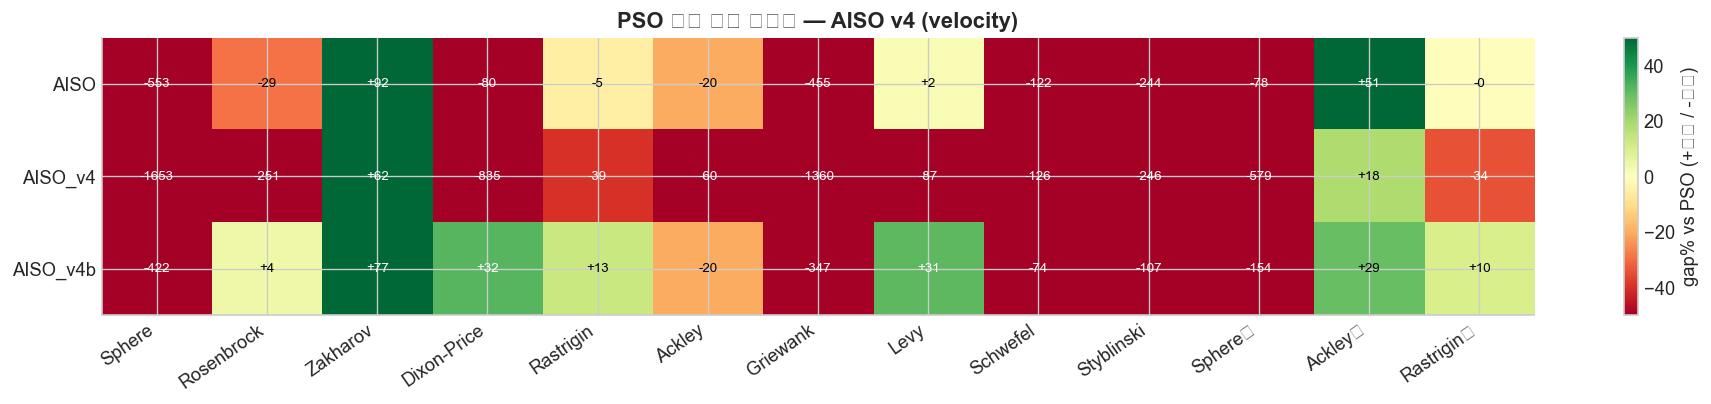

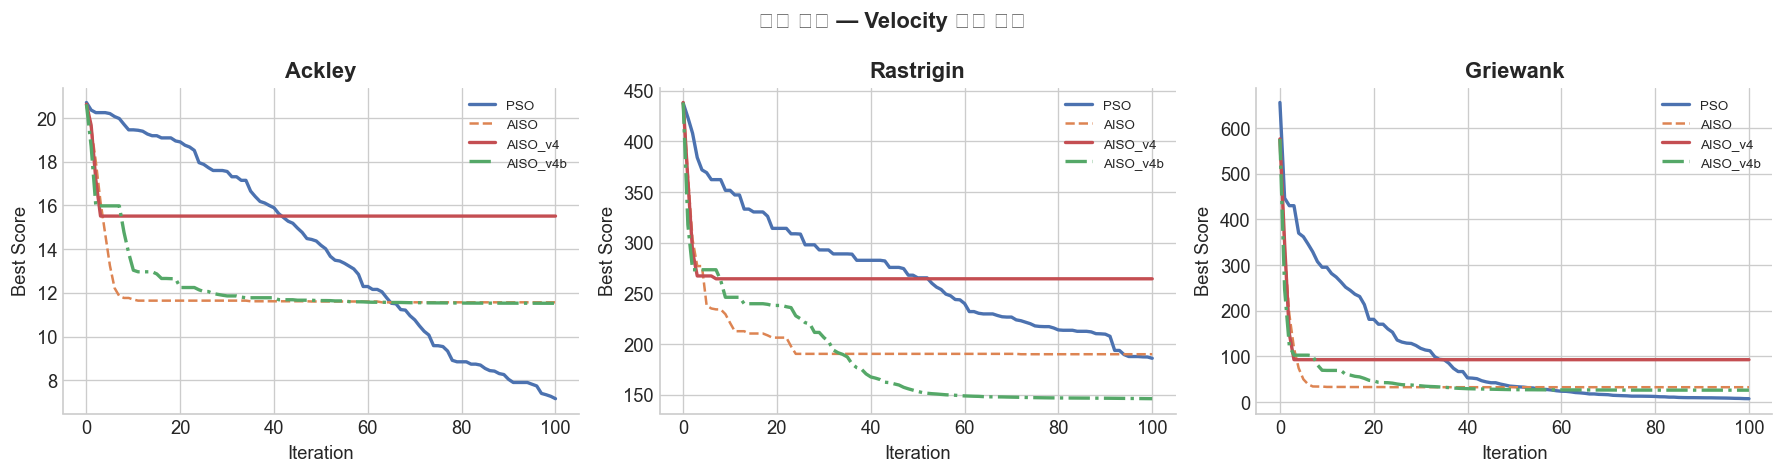

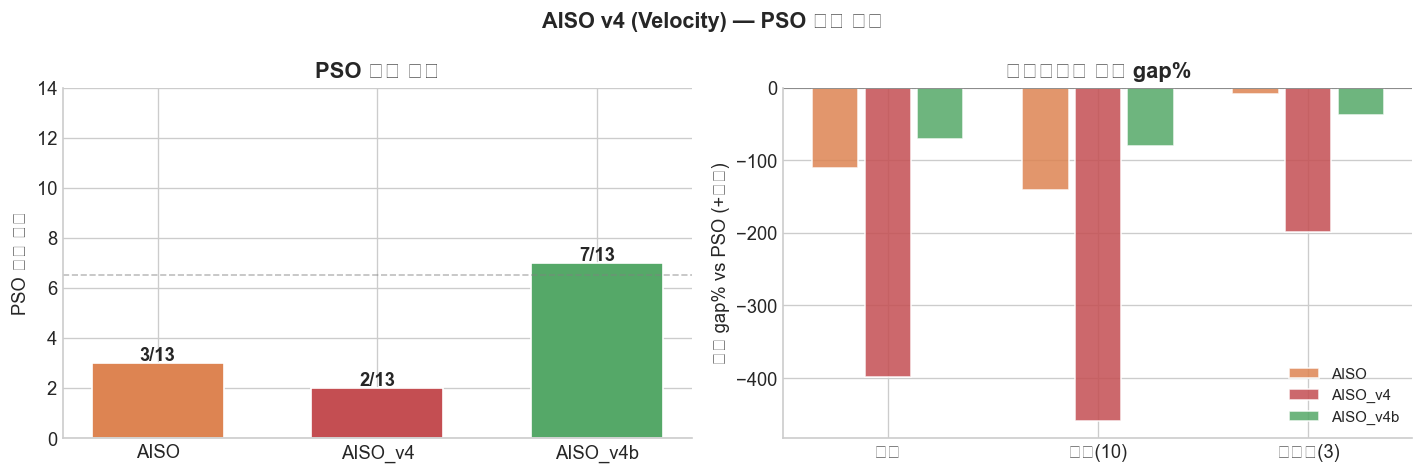

  AISO v4 결과 요약
  AISO          :  3/13승 | 전체gap -111.0% | 노이즈gap -9.2%
  AISO_v4       :  2/13승 | 전체gap -399.3% | 노이즈gap -198.3%
  AISO_v4b      :  7/13승 | 전체gap -71.3% | 노이즈gap -38.4%


In [5]:
import pandas as pd

fnames = list(all_results.keys())
anames = list(ALGOS.keys())
COLORS = {'PSO':'#4C72B0','AISO':'#DD8452','AISO_v4':'#C44E52','AISO_v4b':'#55A868'}
standard_fns = [f for f in fnames if '_N' not in f]
noisy_fns    = [f for f in fnames if '_N' in f]

# ── 히트맵 ───────────────────────────────────────────────────
gap_mat = np.zeros((len(anames)-1, len(fnames)))
row_labels = [a for a in anames if a != 'PSO']
for ri, an in enumerate(row_labels):
    for ci, fn in enumerate(fnames):
        pso_m = np.mean(all_results[fn]['PSO'])
        ai_m  = np.mean(all_results[fn][an])
        gap_mat[ri, ci] = -(ai_m - pso_m) / (abs(pso_m)+1e-8) * 100

fig, ax = plt.subplots(figsize=(16, 3.5))
im = ax.imshow(gap_mat, cmap='RdYlGn', aspect='auto', vmin=-50, vmax=50)
plt.colorbar(im, ax=ax, label='gap% vs PSO (+좋음 / -나쁨)')
ax.set_xticks(range(len(fnames)))
ax.set_xticklabels([f.replace('_N','★') for f in fnames], rotation=35, ha='right')
ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
ax.set_title('PSO 대비 성능 히트맵 — AISO v4 (velocity)', fontweight='bold')
for ri in range(len(row_labels)):
    for ci in range(len(fnames)):
        v = gap_mat[ri, ci]
        ax.text(ci, ri, f'{v:+.0f}', ha='center', va='center', fontsize=8,
                color='black' if abs(v)<30 else 'white')
plt.tight_layout()
plt.savefig('aiso_v4_heatmap.png', bbox_inches='tight')
plt.show()

# ── 수렴 곡선 ─────────────────────────────────────────────────
TRACK_FNS = [make_ackley(), make_rastrigin(), make_griewank()]

def get_curve_pso(fn, seed):
    np.random.seed(seed)
    w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AGENTS,K); V=np.random.uniform(-0.1,0.1,(N_AGENTS,K))
    S=np.array([fn(X[i]) for i in range(N_AGENTS)])
    pX=X.copy(); pS=S.copy(); gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    hist=[gS]
    for _ in range(N_ITER):
        r1,r2=np.random.rand(N_AGENTS,K),np.random.rand(N_AGENTS,K)
        V=w*V+c1*r1*(pX-X)+c2*r2*(gX-X); X=np.clip(X+V,0,1)
        S=np.array([fn(X[i]) for i in range(N_AGENTS)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
        if pS.min()<gS: gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
        hist.append(gS)
    return hist

def get_curve_aiso(fn, seed, use_vel=False, use_gbest=False):
    np.random.seed(seed)
    M=np.random.uniform(0,2,(N_TYPES,N_TYPES))
    X=np.random.rand(N_AGENTS,K)
    V=np.random.uniform(-0.05,0.05,(N_AGENTS,K))
    W=np.random.dirichlet(np.ones(N_TYPES),N_AGENTS)
    S=np.array([fn(X[i]) for i in range(N_AGENTS)])
    gi=np.argmin(S); gX=X[gi].copy(); gS=S[gi]; bS=gS; hist=[bS]
    for _ in range(N_ITER):
        for i in range(N_AGENTS):
            j=np.random.randint(N_AGENTS)
            while j==i: j=np.random.randint(N_AGENTS)
            c=float(W[i]@M@W[j])
            if use_vel:
                cg=float(W[i]@M@W[gi]) if use_gbest else 0.0
                V[i]=W_INERTIA*V[i]+ALPHA*c*(X[j]-X[i])+(0.5*cg*(gX-X[i]) if use_gbest else 0)
                V[i]=np.clip(V[i],-V_CLAMP,V_CLAMP)
                nX=np.clip(X[i]+V[i],0,1); ns=fn(nX)
                X[i]=nX
                if ns<S[i]: W[i]=(1-BETA)*W[i]+BETA*W[j]; W[i]/=W[i].sum()
                S[i]=ns
            else:
                nX=np.clip(X[i]+ALPHA*c*(X[j]-X[i]),0,1); ns=fn(nX)
                if ns<S[i]: X[i]=nX; S[i]=ns; W[i]=(1-BETA)*W[i]+BETA*W[j]; W[i]/=W[i].sum()
        cur=S.min()
        if cur<bS: bS=cur
        if use_gbest:
            ngi=np.argmin(S)
            if S[ngi]<gS: gi=ngi; gX=X[gi].copy(); gS=S[gi]
        hist.append(bS)
    return hist

SEEDS=[42,43,44]
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax, fn in zip(axes, TRACK_FNS):
    curves={'PSO':[],'AISO':[],'AISO_v4':[],'AISO_v4b':[]}
    for s in SEEDS:
        curves['PSO'].append(get_curve_pso(fn,s))
        curves['AISO'].append(get_curve_aiso(fn,s,use_vel=False))
        curves['AISO_v4'].append(get_curve_aiso(fn,s,use_vel=True,use_gbest=False))
        curves['AISO_v4b'].append(get_curve_aiso(fn,s,use_vel=True,use_gbest=True))
    STYLES={'PSO':'-','AISO':'--','AISO_v4':'-','AISO_v4b':'-.'}
    LW={'PSO':2,'AISO':1.5,'AISO_v4':2,'AISO_v4b':2}
    for name,color in COLORS.items():
        mean=np.array(curves[name]).mean(axis=0)
        ax.plot(mean,color=color,linewidth=LW[name],linestyle=STYLES[name],label=name)
    ax.set_title(fn.__name__,fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Best Score')
    ax.legend(frameon=False,fontsize=8)
plt.suptitle('수렴 곡선 — Velocity 추가 효과',fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_v4_convergence.png',bbox_inches='tight')
plt.show()

# ── 승수 & gap% 요약 ─────────────────────────────────────────
fig,axes=plt.subplots(1,2,figsize=(12,4))
ax=axes[0]
for i,an in enumerate(row_labels):
    wins=sum(np.mean(all_results[fn][an])<np.mean(all_results[fn]['PSO']) for fn in fnames)
    ax.bar(i,wins,color=COLORS[an],edgecolor='white',width=0.6)
    ax.text(i,wins+0.1,f'{wins}/{len(fnames)}',ha='center',fontsize=11,fontweight='bold')
ax.set_xticks(range(len(row_labels))); ax.set_xticklabels(row_labels)
ax.set_ylim(0,len(fnames)+1); ax.set_ylabel('PSO 대비 승수')
ax.set_title('PSO 대비 승수', fontweight='bold')
ax.axhline(len(fnames)/2,color='gray',linestyle='--',linewidth=1,alpha=0.5)

ax=axes[1]
cats=['전체','표준(10)','노이즈(3)']
fn_groups=[fnames,standard_fns,noisy_fns]
for i,an in enumerate(row_labels):
    gs=[np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in grp]) for grp in fn_groups]
    xs=np.array([0,1,2])+i*0.25
    ax.bar(xs,gs,width=0.22,color=COLORS[an],alpha=0.85,edgecolor='white',label=an)
ax.axhline(0,color='gray',linewidth=1)
ax.set_xticks([0.25,1.25,2.25]); ax.set_xticklabels(cats)
ax.set_ylabel('평균 gap% vs PSO (+좋음)')
ax.set_title('카테고리별 평균 gap%', fontweight='bold')
ax.legend(frameon=False,fontsize=9)
plt.suptitle('AISO v4 (Velocity) — PSO 추격 결과',fontweight='bold',fontsize=13)
plt.tight_layout()
plt.savefig('aiso_v4_summary.png',bbox_inches='tight')
plt.show()

# ── 텍스트 요약 ──────────────────────────────────────────────
print('='*60)
print('  AISO v4 결과 요약')
print('='*60)
for an in row_labels:
    wins=sum(np.mean(all_results[fn][an])<np.mean(all_results[fn]['PSO']) for fn in fnames)
    g_all=np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in fnames])
    g_n  =np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in noisy_fns])
    print(f'  {an:<14}: {wins:2d}/13승 | 전체gap {g_all:+.1f}% | 노이즈gap {g_n:+.1f}%')
print('='*60)